STUDENT PERFORMANCE INDICATOR

Life Cycle of Machine Learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory Data Analysis
- Model Training
- Choose best model

In [2]:
## import Libraries

import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')   

In [4]:
## Load Dataset
df = pd.read_csv('/Users/rajusubba/Documents/MLOpsProject/machinelearningproject/notebook/data/StudentsPerformance.csv')


Dataset information
Gender: male/female
race/ethinicity: Group a,b,c,d,e
parents level of education: bachelor, masters, associate, high school
lunch: having lunch before test( standard or free/reduced)
test preparation course: complete or not complete
math score
reading score
writing score




Data Check Performace

-check missing values
-check duplicates
-check data type
-check the number of unique of each column
-check statistics of data set
-check various categories present in the different categorical column

In [6]:
##check missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
## check duplicates
df.duplicated().sum()

np.int64(0)

In [8]:
##check data types and data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
## check the number of unique of each column
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [10]:
##heck statistics of data set
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [12]:
## check various categories present in the different categorical column
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].unique())
    # optional: see frequency of each category
    print(df[col].value_counts(dropna=False))


Column: gender
['female' 'male']
gender
female    518
male      482
Name: count, dtype: int64

Column: race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Column: parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Column: lunch
['standard' 'free/reduced']
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Column: test preparation course
['none' 'completed']
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [13]:
# define numerical and categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'object']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'object'] 

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 3 numerical features : ['math score', 'reading score', 'writing score']
We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [14]:
# first 5 record
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [15]:
# Adding a columns for total score
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average score'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [20]:
# number of students that scores more than 95 in each subaject and less than 20 in each subject
print(" Number of students scoring more than 95 in Math:", df[df['math score'] > 95].shape[0])
print(" Number of students scoring more than 95 in Reading:", df[df['reading score'] > 95].shape[0])
print(" Number of students scoring more than 95 in Writing:", df[df['writing score'] > 95].shape[0])
print(" Number of students scoring less than 20 in Math:", df[df['math score'] < 20].shape[0])
print(" Number of students scoring less than 20 in Reading:", df[df['reading score'] < 20].shape[0])
print(" Number of students scoring less than 20 in Writing:", df[df['writing score'] < 20].shape[0])


 Number of students scoring more than 95 in Math: 22
 Number of students scoring more than 95 in Reading: 29
 Number of students scoring more than 95 in Writing: 26
 Number of students scoring less than 20 in Math: 4
 Number of students scoring less than 20 in Reading: 1
 Number of students scoring less than 20 in Writing: 3


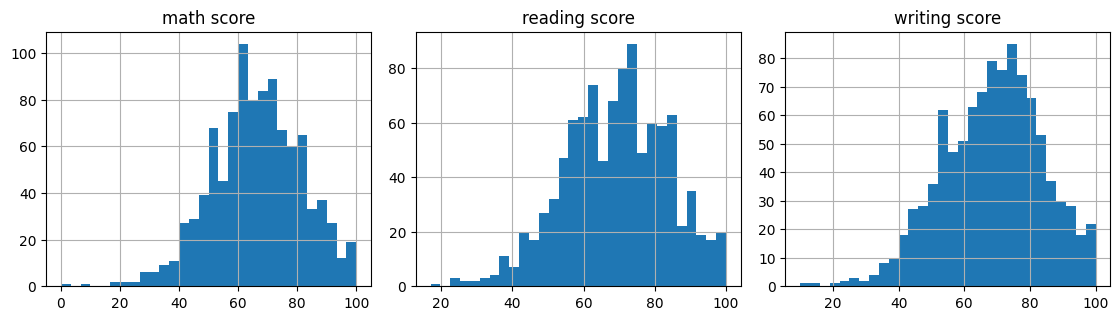

In [29]:
# Distribution and histograms of numerical features
df[numeric_features].hist(bins=30, figsize=(15, 6), layout=(2, 4))
plt.tight_layout()
plt.show()

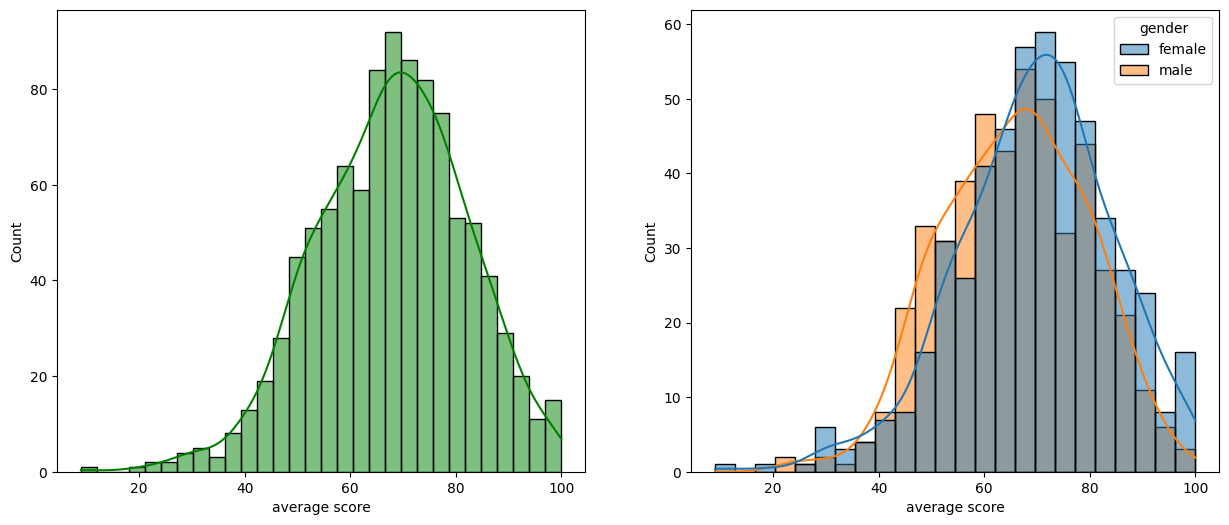

In [28]:
## Average of total and average of total score with respect to male female in histogram
fig, axs = plt.subplots(1, 2, figsize = (15,6))
plt.subplot(121)
sns.histplot(data=df, x='average score', bins = 30, kde = True, color = 'g')
plt.subplot(122)
sns.histplot(data=df, x='average score', kde = True, color = 'b', hue= 'gender')
plt.show()


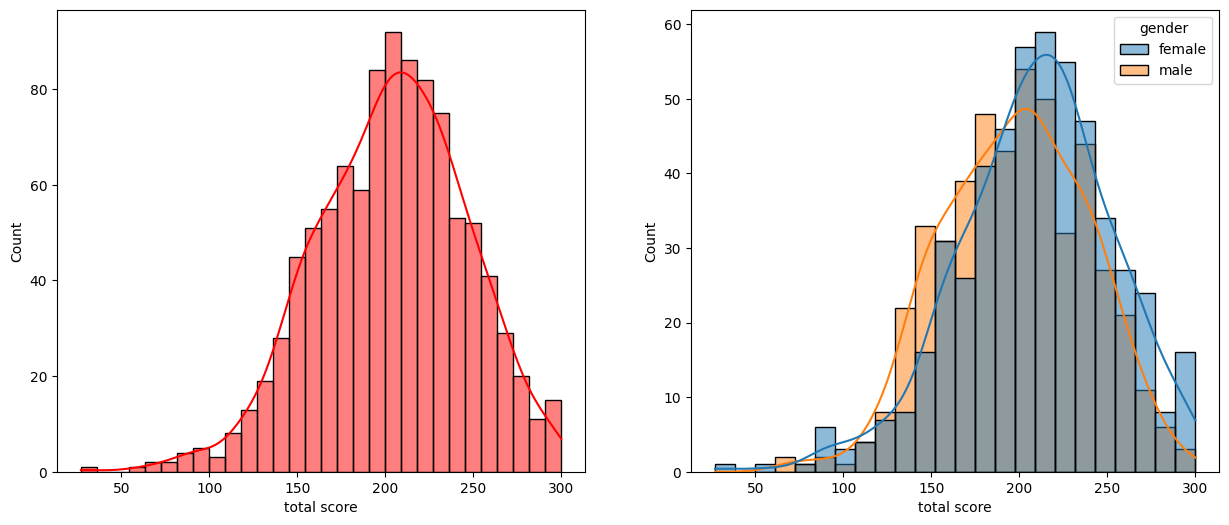

In [30]:
fig, axs = plt.subplots(1,2, figsize=(15,6))
plt.subplot(121)
sns.histplot(data=df, x='total score', bins = 30, kde = True, color = 'r')
plt.subplot(122)
sns.histplot(data=df, x='total score', kde = True, color = 'm', hue= 'gender')
plt.show()